# NB04: 카드매출 데이터 집계

**목적**: 36개월 카드매출 CSV를 동별/업종별/시간대별로 집계하여 배달 수요 지수 산출

**입력**: `00_data/민간데이터/10. 매출(대민)(day)-*/10. 매출(대민)(day)/tbsh_gyeonggi_day_*.csv` (36 files, ~2.5M rows each)  
**출력**: `processed/card_sales_agg.parquet` (동별 월간 집계), `processed/card_delivery_demand.parquet` (동별 배달수요지수)

**주요 변수**:
- `admi_cty_no`: 행정동코드 (41131xxx 체계)
- `card_tpbuz_nm_1/2`: 대분류/소분류 업종
- `hour`: 시간대 (1~10, 약 2시간 단위 구간)
- `amt`: 매출액, `cnt`: 건수

In [1]:
import pandas as pd
import numpy as np
import glob
from pathlib import Path

BASE = Path(r"C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam")
RAW = BASE / "00_data"
OUT = BASE / "processed"

# 모든 카드매출 파일 탐색
card_files = sorted(glob.glob(str(RAW / "민간데이터" / "10*" / "10*" / "*.csv")))
print(f"총 카드매출 파일: {len(card_files)}개")
print(f"기간: {card_files[0].split('day_')[1][:4]} ~ {card_files[-1].split('day_')[1][:4]}")

총 카드매출 파일: 36개
기간: 2305 ~ 2501


## 1. 월별 순차 처리 → 동별 집계

파일당 ~250만 행이므로 한번에 로드하지 않고 월별로 처리하여 메모리 관리

In [2]:
# 배달 수요 관련 업종 정의 (배달 가능한 음식/소매)
DELIVERY_CATEGORIES_L1 = {"음식", "소매/유통"}
DELIVERY_FOOD_L2 = {
    "한식", "분식", "패스트푸드", "고기요리", "일식/수산물",
    "닭/오리요리", "별식/퓨전요리", "중식", "양식", "음식배달서비스",
    "커피/음료", "제과/제빵/떡/케익",
}
DELIVERY_RETAIL_L2 = {
    "종합소매점", "음/식료품소매", "건강/기호식품",
}

def classify_delivery(row):
    """배달 수요 관련 업종 분류"""
    if row["card_tpbuz_nm_1"] == "음식" and row["card_tpbuz_nm_2"] in DELIVERY_FOOD_L2:
        return "delivery_food"
    elif row["card_tpbuz_nm_1"] == "소매/유통" and row["card_tpbuz_nm_2"] in DELIVERY_RETAIL_L2:
        return "delivery_retail"
    else:
        return "other"

def read_card_csv(fpath):
    """구분자·인코딩 자동 감지하여 카드매출 CSV 로드"""
    for enc in ("cp949", "utf-8", "euc-kr"):
        try:
            with open(fpath, "r", encoding=enc) as f:
                first_line = f.readline()
            sep = "|" if "|" in first_line else ","
            return pd.read_csv(fpath, encoding=enc, sep=sep)
        except (UnicodeDecodeError, UnicodeError):
            continue
    raise ValueError(f"Cannot decode {fpath}")

# 월별 순차 집계
monthly_aggs = []
monthly_delivery = []

for i, fpath in enumerate(card_files):
    # 파일명에서 YYMM 추출
    fname = Path(fpath).stem
    yymm = fname.split("day_")[1].split("_")[0]
    
    df = read_card_csv(fpath)
    
    # 1) 동별 전체 매출 집계
    agg = (
        df.groupby(["admi_cty_no", "card_tpbuz_nm_1", "hour"])
        .agg(total_amt=("amt", "sum"), total_cnt=("cnt", "sum"))
        .reset_index()
    )
    agg["ym"] = yymm
    monthly_aggs.append(agg)
    
    # 2) 배달 수요 집계 (배달 관련 업종만)
    df["delivery_type"] = df.apply(classify_delivery, axis=1)
    del_df = df[df["delivery_type"] != "other"]
    del_agg = (
        del_df.groupby(["admi_cty_no", "delivery_type", "hour"])
        .agg(del_amt=("amt", "sum"), del_cnt=("cnt", "sum"))
        .reset_index()
    )
    del_agg["ym"] = yymm
    monthly_delivery.append(del_agg)
    
    if (i + 1) % 6 == 0 or i == len(card_files) - 1:
        print(f"  처리 완료: {i+1}/{len(card_files)} ({yymm})")

print(f"\n전체 처리 완료!")

  처리 완료: 6/36 (2409)


  처리 완료: 12/36 (2504)


  처리 완료: 18/36 (2306)


  처리 완료: 24/36 (2508)


  처리 완료: 30/36 (2312)


  처리 완료: 36/36 (2501)

전체 처리 완료!


In [3]:
# 합치기
df_sales = pd.concat(monthly_aggs, ignore_index=True)
df_delivery = pd.concat(monthly_delivery, ignore_index=True)

print(f"전체 매출 집계: {len(df_sales):,} rows")
print(f"배달 수요 집계: {len(df_delivery):,} rows")
print(f"\n기간: {df_sales['ym'].min()} ~ {df_sales['ym'].max()}")
print(f"행정동 수: {df_sales['admi_cty_no'].nunique()}")

전체 매출 집계: 136,736 rows
배달 수요 집계: 36,000 rows

기간: 2301 ~ 2512
행정동 수: 50


## 2. 동별 배달 수요 지수 산출

배달 수요 지수 = 배달 관련 업종 매출액 기반 (음식배달 + 음식점 + 편의점/마트)  
시간대 가중치: 점심/저녁 피크 시간에 높은 가중치 부여

In [4]:
# 시간대 가중치 (hour 1~10, 약 2시간 구간 추정)
# 점심(hour 6~7 ≈ 11-14시)과 저녁(hour 9~10 ≈ 17-21시) 피크에 높은 가중치
HOUR_WEIGHTS = {
    1: 0.3, 2: 0.3, 3: 0.4, 4: 0.5, 5: 0.7,
    6: 1.0, 7: 1.0, 8: 0.8, 9: 1.2, 10: 1.2,
}

# 동별 배달 수요 지수 계산
df_delivery["hour_weight"] = df_delivery["hour"].map(HOUR_WEIGHTS)
df_delivery["weighted_amt"] = df_delivery["del_amt"] * df_delivery["hour_weight"]

# 동별 월평균 배달 수요 (최근 12개월 기준)
recent_months = sorted(df_delivery["ym"].unique())[-12:]
recent_del = df_delivery[df_delivery["ym"].isin(recent_months)]

demand_by_dong = (
    recent_del.groupby("admi_cty_no")
    .agg(
        avg_monthly_del_amt=("del_amt", lambda x: x.sum() / 12),
        avg_monthly_del_cnt=("del_cnt", lambda x: x.sum() / 12),
        avg_monthly_weighted_amt=("weighted_amt", lambda x: x.sum() / 12),
    )
    .reset_index()
)

# 0-1 정규화
for col in ["avg_monthly_del_amt", "avg_monthly_del_cnt", "avg_monthly_weighted_amt"]:
    vmin, vmax = demand_by_dong[col].min(), demand_by_dong[col].max()
    demand_by_dong[f"{col}_norm"] = (demand_by_dong[col] - vmin) / (vmax - vmin)

# 종합 배달 수요 지수 (매출액 0.6 + 건수 0.4)
demand_by_dong["delivery_demand_index"] = (
    0.6 * demand_by_dong["avg_monthly_weighted_amt_norm"]
    + 0.4 * demand_by_dong["avg_monthly_del_cnt_norm"]
)

print(f"동별 배달 수요 지수 (최근 12개월 기준, {recent_months[0]}~{recent_months[-1]}):")
print(demand_by_dong.sort_values("delivery_demand_index", ascending=False).head(10)[
    ["admi_cty_no", "avg_monthly_del_amt", "delivery_demand_index"]
])

동별 배달 수요 지수 (최근 12개월 기준, 2501~2512):
    admi_cty_no  avg_monthly_del_amt  delivery_demand_index
36     41135580         3.865476e+10               0.996813
29     41135520         3.884270e+10               0.820864
40     41135620         2.242881e+10               0.554029
33     41135550         2.062440e+10               0.530390
48     41135670         2.065336e+10               0.462524
17     41133510         1.686524e+10               0.458556
44     41135655         1.748235e+10               0.446593
13     41131625         1.673360e+10               0.443049
6      41131561         1.739623e+10               0.347841
47     41135665         1.392997e+10               0.315137


## 3. 시간대별 매출 패턴 (Dashboard 4: Temporal Demand Patterns 용)

In [5]:
# 동별-시간대별 배달수요 집계 (Tableau 시간대 애니메이션용)
hourly_demand = (
    df_delivery.groupby(["admi_cty_no", "hour"])
    .agg(total_del_amt=("del_amt", "sum"), total_del_cnt=("del_cnt", "sum"))
    .reset_index()
)
# 동별 총합 대비 시간대별 비율
dong_totals = hourly_demand.groupby("admi_cty_no")["total_del_amt"].transform("sum")
hourly_demand["hour_ratio"] = hourly_demand["total_del_amt"] / dong_totals

print(f"시간대별 패턴: {len(hourly_demand):,} rows")
print(f"\n전체 시간대별 배달 매출 분포:")
print(hourly_demand.groupby("hour")["total_del_amt"].sum().apply(lambda x: f"{x:,.0f}"))

시간대별 패턴: 500 rows

전체 시간대별 배달 매출 분포:
hour
1       409,840,181,773
2       282,460,048,178
3       830,429,422,606
4     2,291,952,460,275
5     2,378,772,843,135
6     2,040,261,600,659
7     2,376,809,760,851
8     2,350,906,786,319
9     1,097,297,910,005
10      234,944,949,345
Name: total_del_amt, dtype: object


## 4. 시각적 검증 + 저장

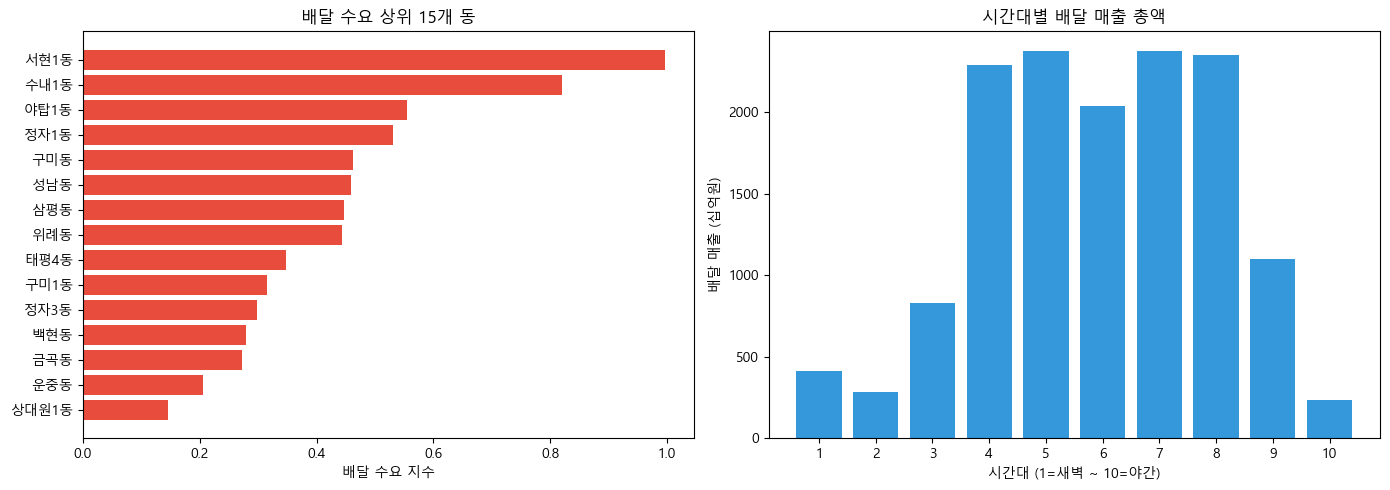

In [6]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 동별 배달 수요 지수 상위 15개
top15 = demand_by_dong.nlargest(15, "delivery_demand_index")

# 행정동코드 -> 이름 매핑 (crosswalk 로드)
cw = pd.read_csv(OUT / "admin_code_crosswalk.csv")
code_to_name = dict(zip(cw["CSV_ADMI_CD"], cw["DONG_NM"]))
top15["dong_nm"] = top15["admi_cty_no"].map(code_to_name)

axes[0].barh(
    top15["dong_nm"][::-1],
    top15["delivery_demand_index"][::-1],
    color="#e74c3c",
)
axes[0].set_xlabel("배달 수요 지수")
axes[0].set_title("배달 수요 상위 15개 동")

# 오른쪽: 시간대별 전체 배달 매출 패턴
hourly_total = hourly_demand.groupby("hour")["total_del_amt"].sum()
axes[1].bar(hourly_total.index, hourly_total.values / 1e9, color="#3498db")
axes[1].set_xlabel("시간대 (1=새벽 ~ 10=야간)")
axes[1].set_ylabel("배달 매출 (십억원)")
axes[1].set_title("시간대별 배달 매출 총액")
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [7]:
# 저장
df_sales.to_parquet(OUT / "card_sales_agg.parquet", index=False)
demand_by_dong.to_parquet(OUT / "card_delivery_demand.parquet", index=False)
hourly_demand.to_parquet(OUT / "card_hourly_demand.parquet", index=False)

print("저장 완료:")
print(f"  - card_sales_agg.parquet ({len(df_sales):,} rows) - 동별/업종별/시간대별 월간 매출")
print(f"  - card_delivery_demand.parquet ({len(demand_by_dong)} rows) - 동별 배달수요지수")
print(f"  - card_hourly_demand.parquet ({len(hourly_demand)} rows) - 동별 시간대 패턴")

저장 완료:
  - card_sales_agg.parquet (136,736 rows) - 동별/업종별/시간대별 월간 매출
  - card_delivery_demand.parquet (50 rows) - 동별 배달수요지수
  - card_hourly_demand.parquet (500 rows) - 동별 시간대 패턴
